# AGROSmart – Leaf Disease Detection

Build a clean CNN pipeline that classifies plant leaf images as **healthy** or **diseased**.

This notebook covers:
- Loading PlantVillage images
- Creating a binary label map (healthy vs diseased)
- Training a simple CNN
- Evaluating with accuracy, confusion matrix, and exports

## 1. Imports

In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import confusion_matrix, classification_report

## 2. Configuration

In [79]:
DATASET_PATH = "dataset/PlantVillage"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10
SEED = 123
HEALTHY_KEYWORD = "healthy"

## 3. Load dataset

In [80]:
train_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print("Classes:", class_names)

healthy_indices = [
    i for i, name in enumerate(class_names)
    if HEALTHY_KEYWORD in name.lower()
]
healthy_indices = tf.constant(healthy_indices, dtype=tf.int32)
print("Healthy label indices:", healthy_indices.numpy())

Found 41276 files belonging to 16 classes.
Using 33021 files for training.
Found 41276 files belonging to 16 classes.
Using 8255 files for validation.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Healthy label indices: [ 1  5 15]


## 4. Preprocessing

In [81]:
normalization_layer = layers.Rescaling(1.0 / 255)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))


def map_to_binary(images, labels):
    labels = tf.cast(labels, tf.int32)
    is_healthy = tf.reduce_any(
        tf.equal(tf.expand_dims(labels, -1), healthy_indices), axis=-1
    )
    return images, tf.cast(is_healthy, tf.int32)

train_ds = train_ds.map(map_to_binary)
val_ds = val_ds.map(map_to_binary)

## 5. Model definition

In [82]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=IMG_SIZE + (3,)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Training

In [83]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 130s 124ms/step - accuracy: 0.9224 - loss: 0.2384 - val_accuracy: 0.9194 - val_loss: 0.2008
Epoch 2/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 125s 121ms/step - accuracy: 0.9226 - loss: 0.1905 - val_accuracy: 0.9194 - val_loss: 0.1939
Epoch 3/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 120s 117ms/step - accuracy: 0.9224 - loss: 0.2007 - val_accuracy: 0.9194 - val_loss: 0.1687
Epoch 4/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 122s 118ms/step - accuracy: 0.9222 - loss: 0.1657 - val_accuracy: 0.9194 - val_loss: 0.1581
Epoch 5/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 134s 130ms/step - accuracy: 0.9227 - loss: 0.1544 - val_accuracy: 0.9194 - val_loss: 0.1548
Epoch 6/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 135s 131ms/step - accuracy: 0.9234 - loss: 0.1425 - val_accuracy: 0.9168 - val_loss: 0.1402
Epoch 7/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 130s 126ms/step - accuracy: 0.9231 - loss: 0.1349 - val_accuracy: 0.9165 - val_loss: 0.1282
Epoch 8/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 146s 129ms/step - ac

## 7. Visualize training

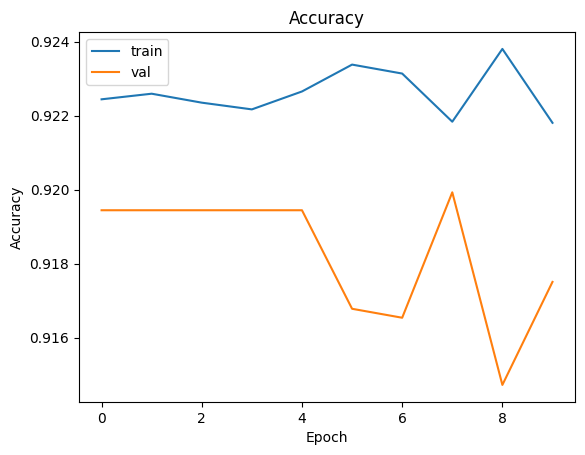

In [84]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend();

## 8. Evaluate

In [85]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation accuracy: {accuracy:.4f}")

258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.9175 - loss: 0.1216
Validation accuracy: 0.9175


## 9. Results

In [86]:
results = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0).flatten()
    for true_label, pred in zip(labels.numpy(), preds):
        results.append({
            "true_label": int(true_label),
            "predicted_label": int(pred > 0.5),
            "confidence": float(pred),
        })

results_df = pd.DataFrame(results)
results_df.to_csv("leaf_classification_results.csv", index=False)
results_df.to_json("leaf_classification_results.json", orient="records")

print("Saved results to CSV + JSON")

Saved results to CSV + JSON


In [87]:
cm = confusion_matrix(results_df["true_label"], results_df["predicted_label"], labels=[0, 1])
print("Confusion matrix:\n", cm)
print("\nClassification report:\n")
print(classification_report(results_df["true_label"], results_df["predicted_label"], target_names=["diseased", "healthy"]))

Confusion matrix:
 [[7307  283]
 [ 398  267]]

Classification report:

              precision    recall  f1-score   support

    diseased       0.95      0.96      0.96      7590
     healthy       0.49      0.40      0.44       665

    accuracy                           0.92      8255
   macro avg       0.72      0.68      0.70      8255
weighted avg       0.91      0.92      0.91      8255

